# Evaluación Comparativa de Modelos
## Tesis: Benchmarking Explainable Gradient Boosting and Tabular Deep Learning
## for Predicting Satisfaction with Democracy in Latin America (1995–2024)

**Objetivo:** Responder PI1 — ¿qué familia de modelos ofrece el mejor equilibrio
entre rendimiento predictivo, estabilidad temporal e interpretabilidad?

Este notebook carga los modelos y resultados generados en `02_preprocesamiento_entrenamiento.ipynb`
y produce el análisis comparativo completo (OE2).

### Estructura
| Sección | Contenido |
|---|---|
| 1–2 | Importaciones y configuración |
| 3 | Tabla maestra de métricas |
| 4 | Visualización comparativa |
| 5 | Matrices de confusión |
| 6 | Análisis de rendimiento por subregión y país |
| 7 | Test estadístico (Friedman + Nemenyi) |
| 8 | Selección del modelo principal para XAI |
| 9 | Guardado de resultados de evaluación |

## 1. Importaciones

In [1]:
import sys
sys.path.append("..")

import warnings
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List

warnings.filterwarnings("ignore")

from utils.config import (
    setup_plots, THEME, PATHS, SPLIT, SUBREGIONES,
    PAISES_EXCLUIR_EVAL, COL_TARGET, COL_PAIS, ETIQUETAS, N_CLASES,
    ETIQUETAS_FEATURES, BLOQUES,
)
from utils.io import (
    cargar_pipeline, cargar_resultados, cargar_split_parquet,
    listar_pipelines_disponibles, cargar_mejor_modelo,
)
from utils.plots import (
    plot_metricas_comparativas, plot_matrices_confusion,
    plot_rendimiento_por_pais, save_figure, model_color,
)
from utils.metrics import evaluar

setup_plots()
print("✓ Importaciones completadas.")

✓ Importaciones completadas.


## 2. Configuración

In [2]:
# =============================================================================
# Parámetros del notebook de evaluación
# =============================================================================

# ── Bandera: matrices de confusión ────────────────────────────────────────────
# True  → una matriz por cada combinación modelo × estrategia (15 matrices)
# False → solo el mejor modelo por conjunto (3 matrices)
CONFUSION_TODOS_MODELOS = True

# ── Bandera: test estadístico ─────────────────────────────────────────────────
# Incluir test de Friedman + post-hoc de Nemenyi entre modelos.
# Con n=1 split único la potencia es baja, pero se documenta para rigor.
EJECUTAR_TEST_ESTADISTICO = True

# ── Métrica principal de comparación ─────────────────────────────────────────
METRICA_PRINCIPAL = "kappa_cuadratico"

# ── Modelos a evaluar ─────────────────────────────────────────────────────────
MODELOS = ["OLO", "XGBoost", "CatBoost", "LightGBM", "TabNet"]

print("Pipelines disponibles:")
print(listar_pipelines_disponibles().to_string(index=False))

Pipelines disponibles:
               modelo                                         ruta  tamaño_kb
 CatBoost_pesos_clase  ../models/pipeline_CatBoost_pesos_clase.pkl      264.2
CatBoost_sin_balanceo ../models/pipeline_CatBoost_sin_balanceo.pkl      908.0
     CatBoost_smotenc      ../models/pipeline_CatBoost_smotenc.pkl      248.8
 LightGBM_pesos_clase  ../models/pipeline_LightGBM_pesos_clase.pkl      232.7
LightGBM_sin_balanceo ../models/pipeline_LightGBM_sin_balanceo.pkl     4472.9
     LightGBM_smotenc      ../models/pipeline_LightGBM_smotenc.pkl      744.2
      OLO_pesos_clase       ../models/pipeline_OLO_pesos_clase.pkl     1785.3
     OLO_sin_balanceo      ../models/pipeline_OLO_sin_balanceo.pkl     1785.4
          OLO_smotenc           ../models/pipeline_OLO_smotenc.pkl      190.7
   TabNet_pesos_clase    ../models/pipeline_TabNet_pesos_clase.pkl     6394.5
  TabNet_sin_balanceo   ../models/pipeline_TabNet_sin_balanceo.pkl     6393.9
       TabNet_smotenc        ../models/pi

## 3. Tabla maestra de métricas

Carga los resultados del conjunto de **prueba** del split único.
Cada split tiene su propio conjunto de validación (usado solo en Optuna)
y conjunto de prueba (reportado aquí).

| split | Train | Validación | Prueba |
|---|---|---|---|
| Test | 1995–2005 | 2006 | 2007 |
| Test | 1995–2016 | 2017 | 2018 |
| Test | 2023, 2024 | — | — |  # conjunto de prueba del split único

In [3]:
# =============================================================================
# Cargar resultados del conjunto de prueba
# =============================================================================
df_test = cargar_resultados(split="test")
df_val  = cargar_resultados(split="val")

print("Métricas en conjunto de PRUEBA:")
cols = ["modelo", "estrategia_balanceo", "balanced_accuracy", "f1_macro",
        "kappa_lineal", "kappa_cuadratico", "mae_ordinal", "auroc_macro"]
print(df_test[[c for c in cols if c in df_test.columns]]
      .sort_values(["estrategia_balanceo", METRICA_PRINCIPAL], ascending=[True, False])
      .to_string(index=False, float_format="{:.4f}".format))

print("\nKappa Cuadrático — pivot (modelo × estrategia):")
pivot = df_test.pivot(index="modelo", columns="estrategia_balanceo",
                      values="kappa_cuadratico")
print(pivot.to_string(float_format="{:.4f}".format))

# Guardar tabla
pivot.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "metricas_kappa_pivot.csv")
df_test.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "metricas_completas_test.csv",
               index=False)
print("\n✓ Tablas guardadas en results/tables/")


Métricas en conjunto de PRUEBA:
  modelo estrategia_balanceo  balanced_accuracy  f1_macro  kappa_lineal  kappa_cuadratico  mae_ordinal  auroc_macro
 XGBoost         pesos_clase             0.4845    0.4896        0.4154            0.5250       0.5725       0.7714
LightGBM         pesos_clase             0.5177    0.4752        0.4205            0.5236       0.6611       0.7817
CatBoost         pesos_clase             0.5133    0.4756        0.4179            0.5213       0.6550       0.7812
     OLO         pesos_clase             0.4893    0.4266        0.3946            0.5189       0.7313       0.7529
  TabNet         pesos_clase             0.4615    0.4416        0.3723            0.5006       0.6794       0.7281
CatBoost        sin_balanceo             0.4658    0.4879        0.4171            0.5385       0.5130       0.7846
 XGBoost        sin_balanceo             0.4674    0.4916        0.3999            0.5125       0.5282       0.7771
LightGBM        sin_balanceo            

## 4. Visualización comparativa

  ✓ Figura guardada: 03_metricas_comparativas.png


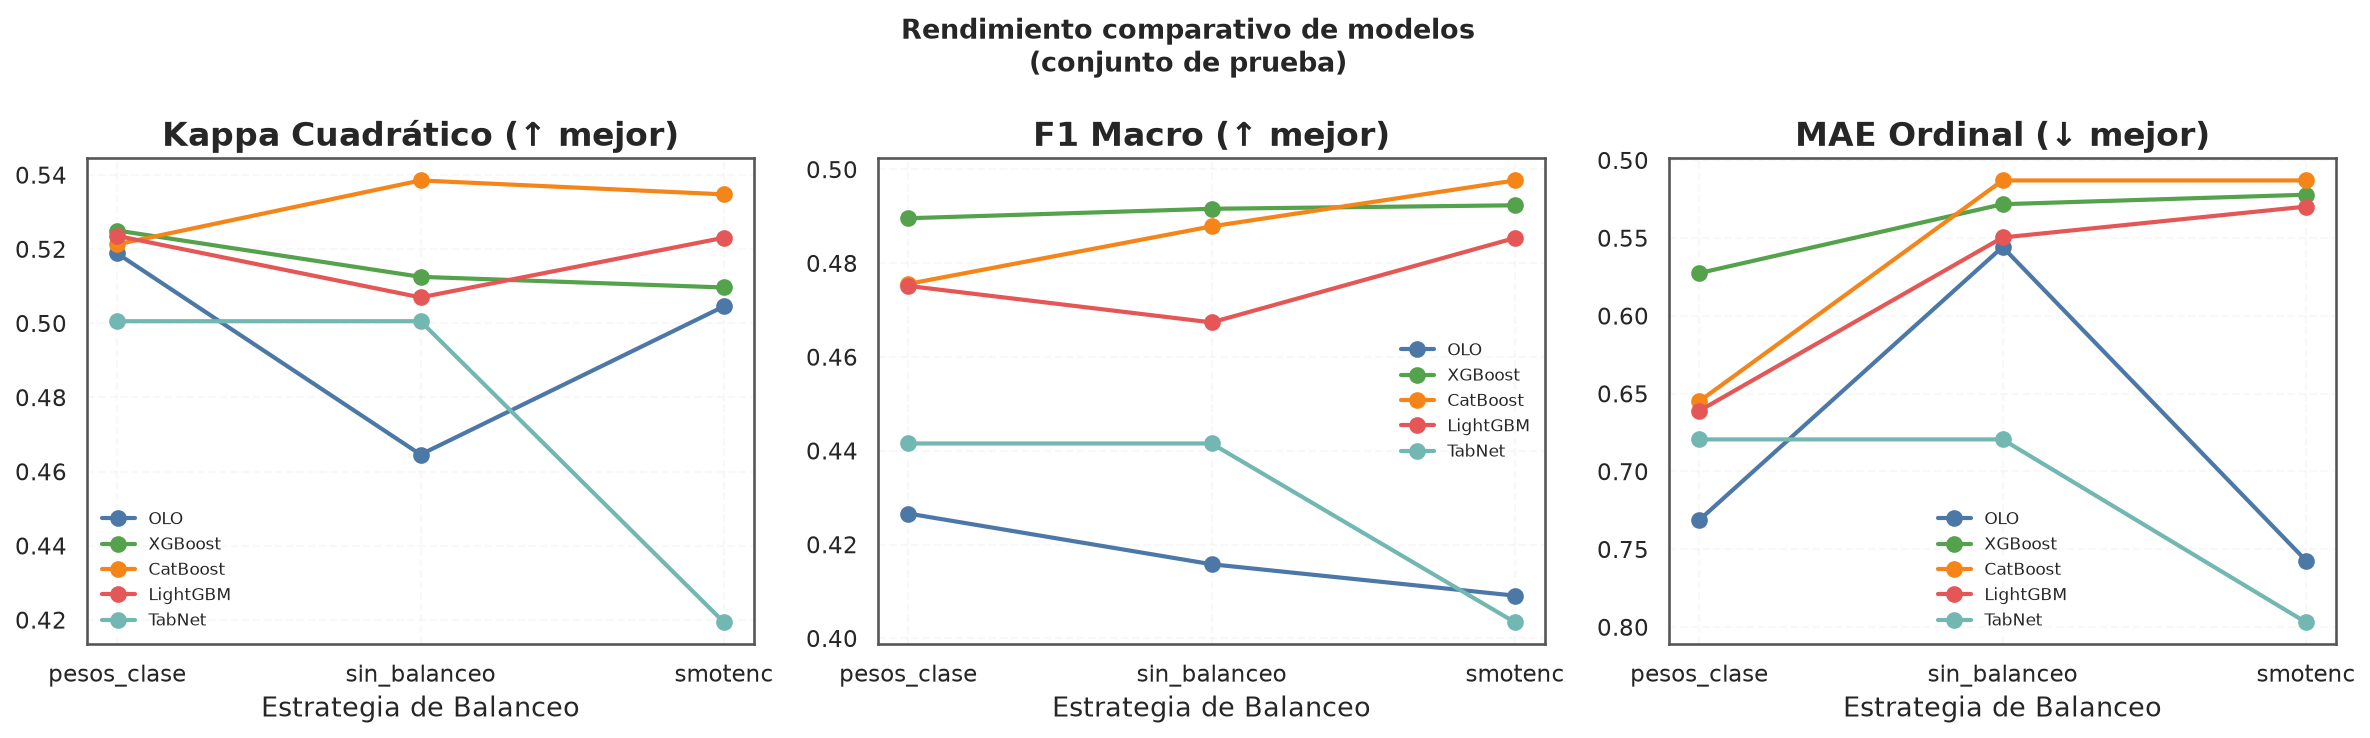

In [4]:
# =============================================================================
# Gráficos de rendimiento por modelo y split
# =============================================================================
plot_metricas_comparativas(df_test, nombre_archivo="03_metricas_comparativas")

  ✓ Figura guardada: 03_val_vs_test.png


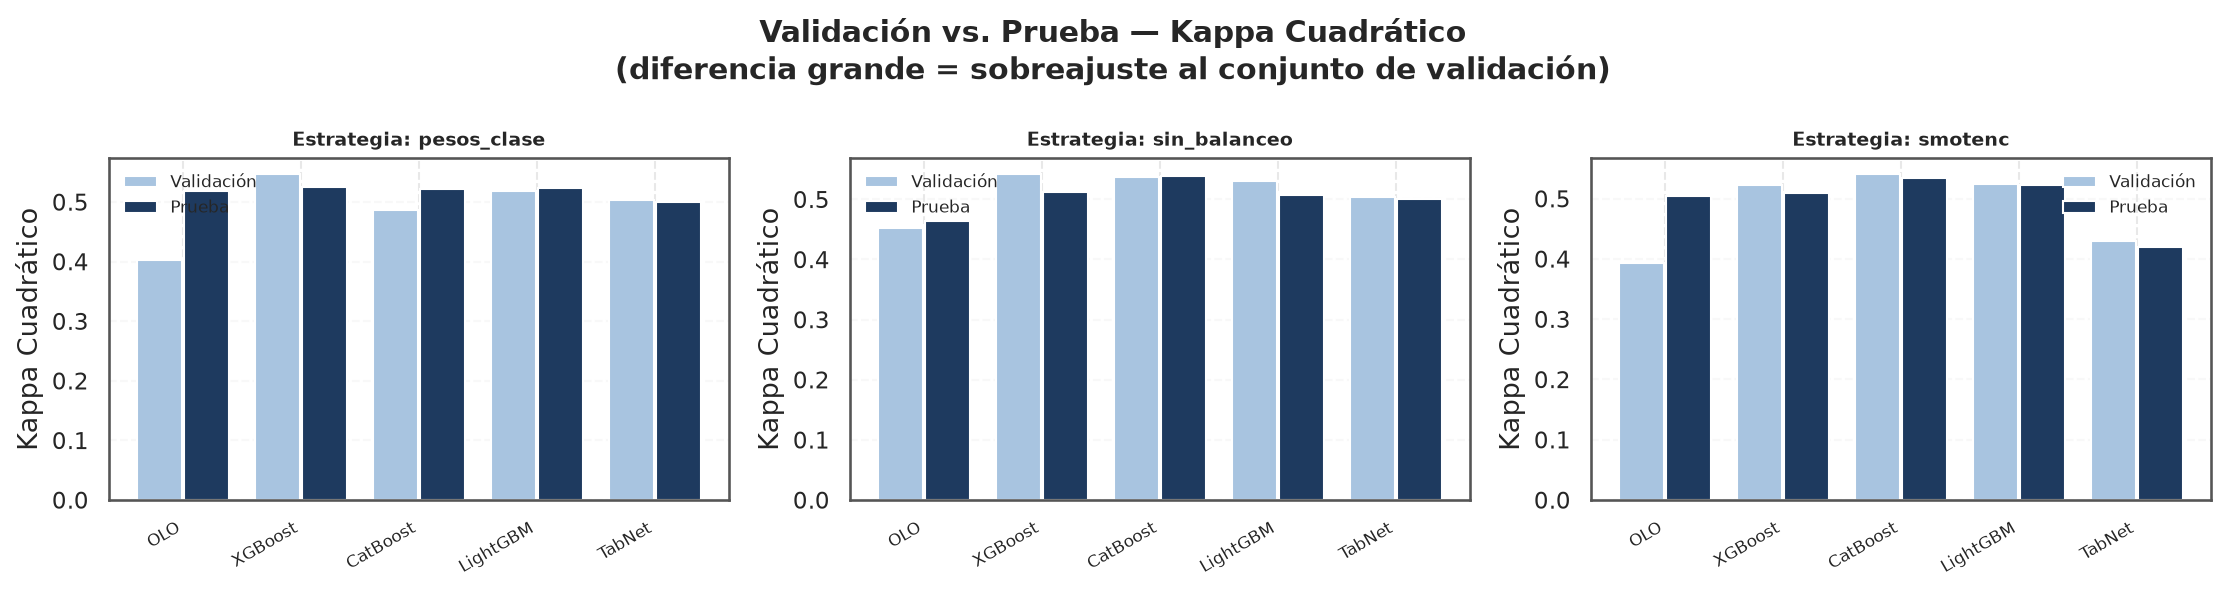

In [5]:
# =============================================================================
# Comparación validación vs. prueba para detectar sobreajuste
# =============================================================================
estrategias = sorted(df_test["estrategia_balanceo"].unique())
fig, axes = plt.subplots(1, len(estrategias), figsize=(5 * len(estrategias), 4))
if len(estrategias) == 1:
    axes = [axes]
fig.suptitle("Validación vs. Prueba — Kappa Cuadrático\n"
             "(diferencia grande = sobreajuste al conjunto de validación)",
             fontweight="bold")

for ax, estrat in zip(axes, estrategias):
    sub_val  = df_val[df_val["estrategia_balanceo"] == estrat].set_index("modelo")["kappa_cuadratico"]
    sub_test = df_test[df_test["estrategia_balanceo"] == estrat].set_index("modelo")["kappa_cuadratico"]

    modelos_comunes = [m for m in MODELOS if m in sub_val.index and m in sub_test.index]
    x = np.arange(len(modelos_comunes))

    ax.bar(x - 0.2, [sub_val[m] for m in modelos_comunes], 0.38,
           label="Validación", color="#A8C4E0", edgecolor="white")
    ax.bar(x + 0.2, [sub_test[m] for m in modelos_comunes], 0.38,
           label="Prueba", color="#1E3A5F", edgecolor="white")
    ax.set_title(f"Estrategia: {estrat}", fontsize=9, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(modelos_comunes, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Kappa Cuadrático")
    ax.legend(fontsize=8)
    ax.grid(True, axis="y", alpha=0.3)

save_figure("03_val_vs_test")
plt.show()


## 5. Matrices de confusión

In [6]:
# =============================================================================
# Reconstruir predicciones para las matrices de confusion
# =============================================================================
import joblib

resultados_cm: Dict = {}   # clave: (modelo, estrategia) -> (y_true, y_pred)

df_te = cargar_split_parquet("test")
y_te  = df_te[COL_TARGET].astype(int).values

for estrat in sorted(df_test["estrategia_balanceo"].unique()):
    for modelo in MODELOS:
        try:
            art   = cargar_pipeline(modelo, estrat)
            tipo  = art["tipo_modelo"]
            feats = art["features"]
            X_te  = df_te[[f for f in feats if f in df_te.columns]]
            X_te  = X_te.reindex(columns=feats)

            if tipo in ("olo", "tabnet"):
                vars_cat = [c for c in art.get("vars_categoricas", []) if c in X_te.columns]
                cols_num = [c for c in feats if c not in vars_cat]
                X_num = pd.DataFrame(
                    art["imp_num"].transform(X_te[cols_num]),
                    columns=cols_num, index=X_te.index)
                if vars_cat and art.get("imp_cat") is not None:
                    X_cat = pd.DataFrame(
                        art["imp_cat"].transform(X_te[vars_cat]),
                        columns=vars_cat, index=X_te.index)
                    X_imp = pd.concat([X_num, X_cat], axis=1)[feats]
                else:
                    X_imp = X_num
                cols_num_sc = [c for c in feats if c not in vars_cat]
                X_sc = X_imp.copy()
                X_sc[cols_num_sc] = art["scaler"].transform(X_imp[cols_num_sc])
                if tipo == "olo":
                    y_pred = art["modelo"].predict(X_sc.values)
                else:
                    y_pred = art["modelo"].predict(X_sc.values.astype(np.float32))
            else:  # trees
                X_in = X_te.copy()
                if modelo == "CatBoost":
                    for col in art.get("vars_categoricas", []):
                        if col in X_in.columns:
                            X_in[col] = X_in[col].fillna(-999).astype(int).astype(str)
                elif modelo == "LightGBM":
                    for col in art.get("vars_categoricas", []):
                        if col in X_in.columns:
                            cats = sorted(X_in[col].dropna().unique().tolist())
                            ct = pd.CategoricalDtype(categories=cats, ordered=False)
                            X_in[col] = X_in[col].astype(ct)
                y_raw  = art["modelo"].predict(X_in)
                y_pred = y_raw.flatten() if hasattr(y_raw, "flatten") else y_raw

            resultados_cm[(modelo, estrat)] = (y_te, y_pred)
        except FileNotFoundError:
            print(f"  Advertencia: Pipeline no encontrado: {modelo} - {estrat}")
        except Exception as e:
            print(f"  Advertencia: Error en {modelo} - {estrat}: {e}")

print(f"Predicciones reconstruidas para {len(resultados_cm)} combinaciones")


Predicciones reconstruidas para 15 combinaciones


Mejor modelo global: CatBoost


  ✓ Figura guardada: 03_matrices_confusion.png


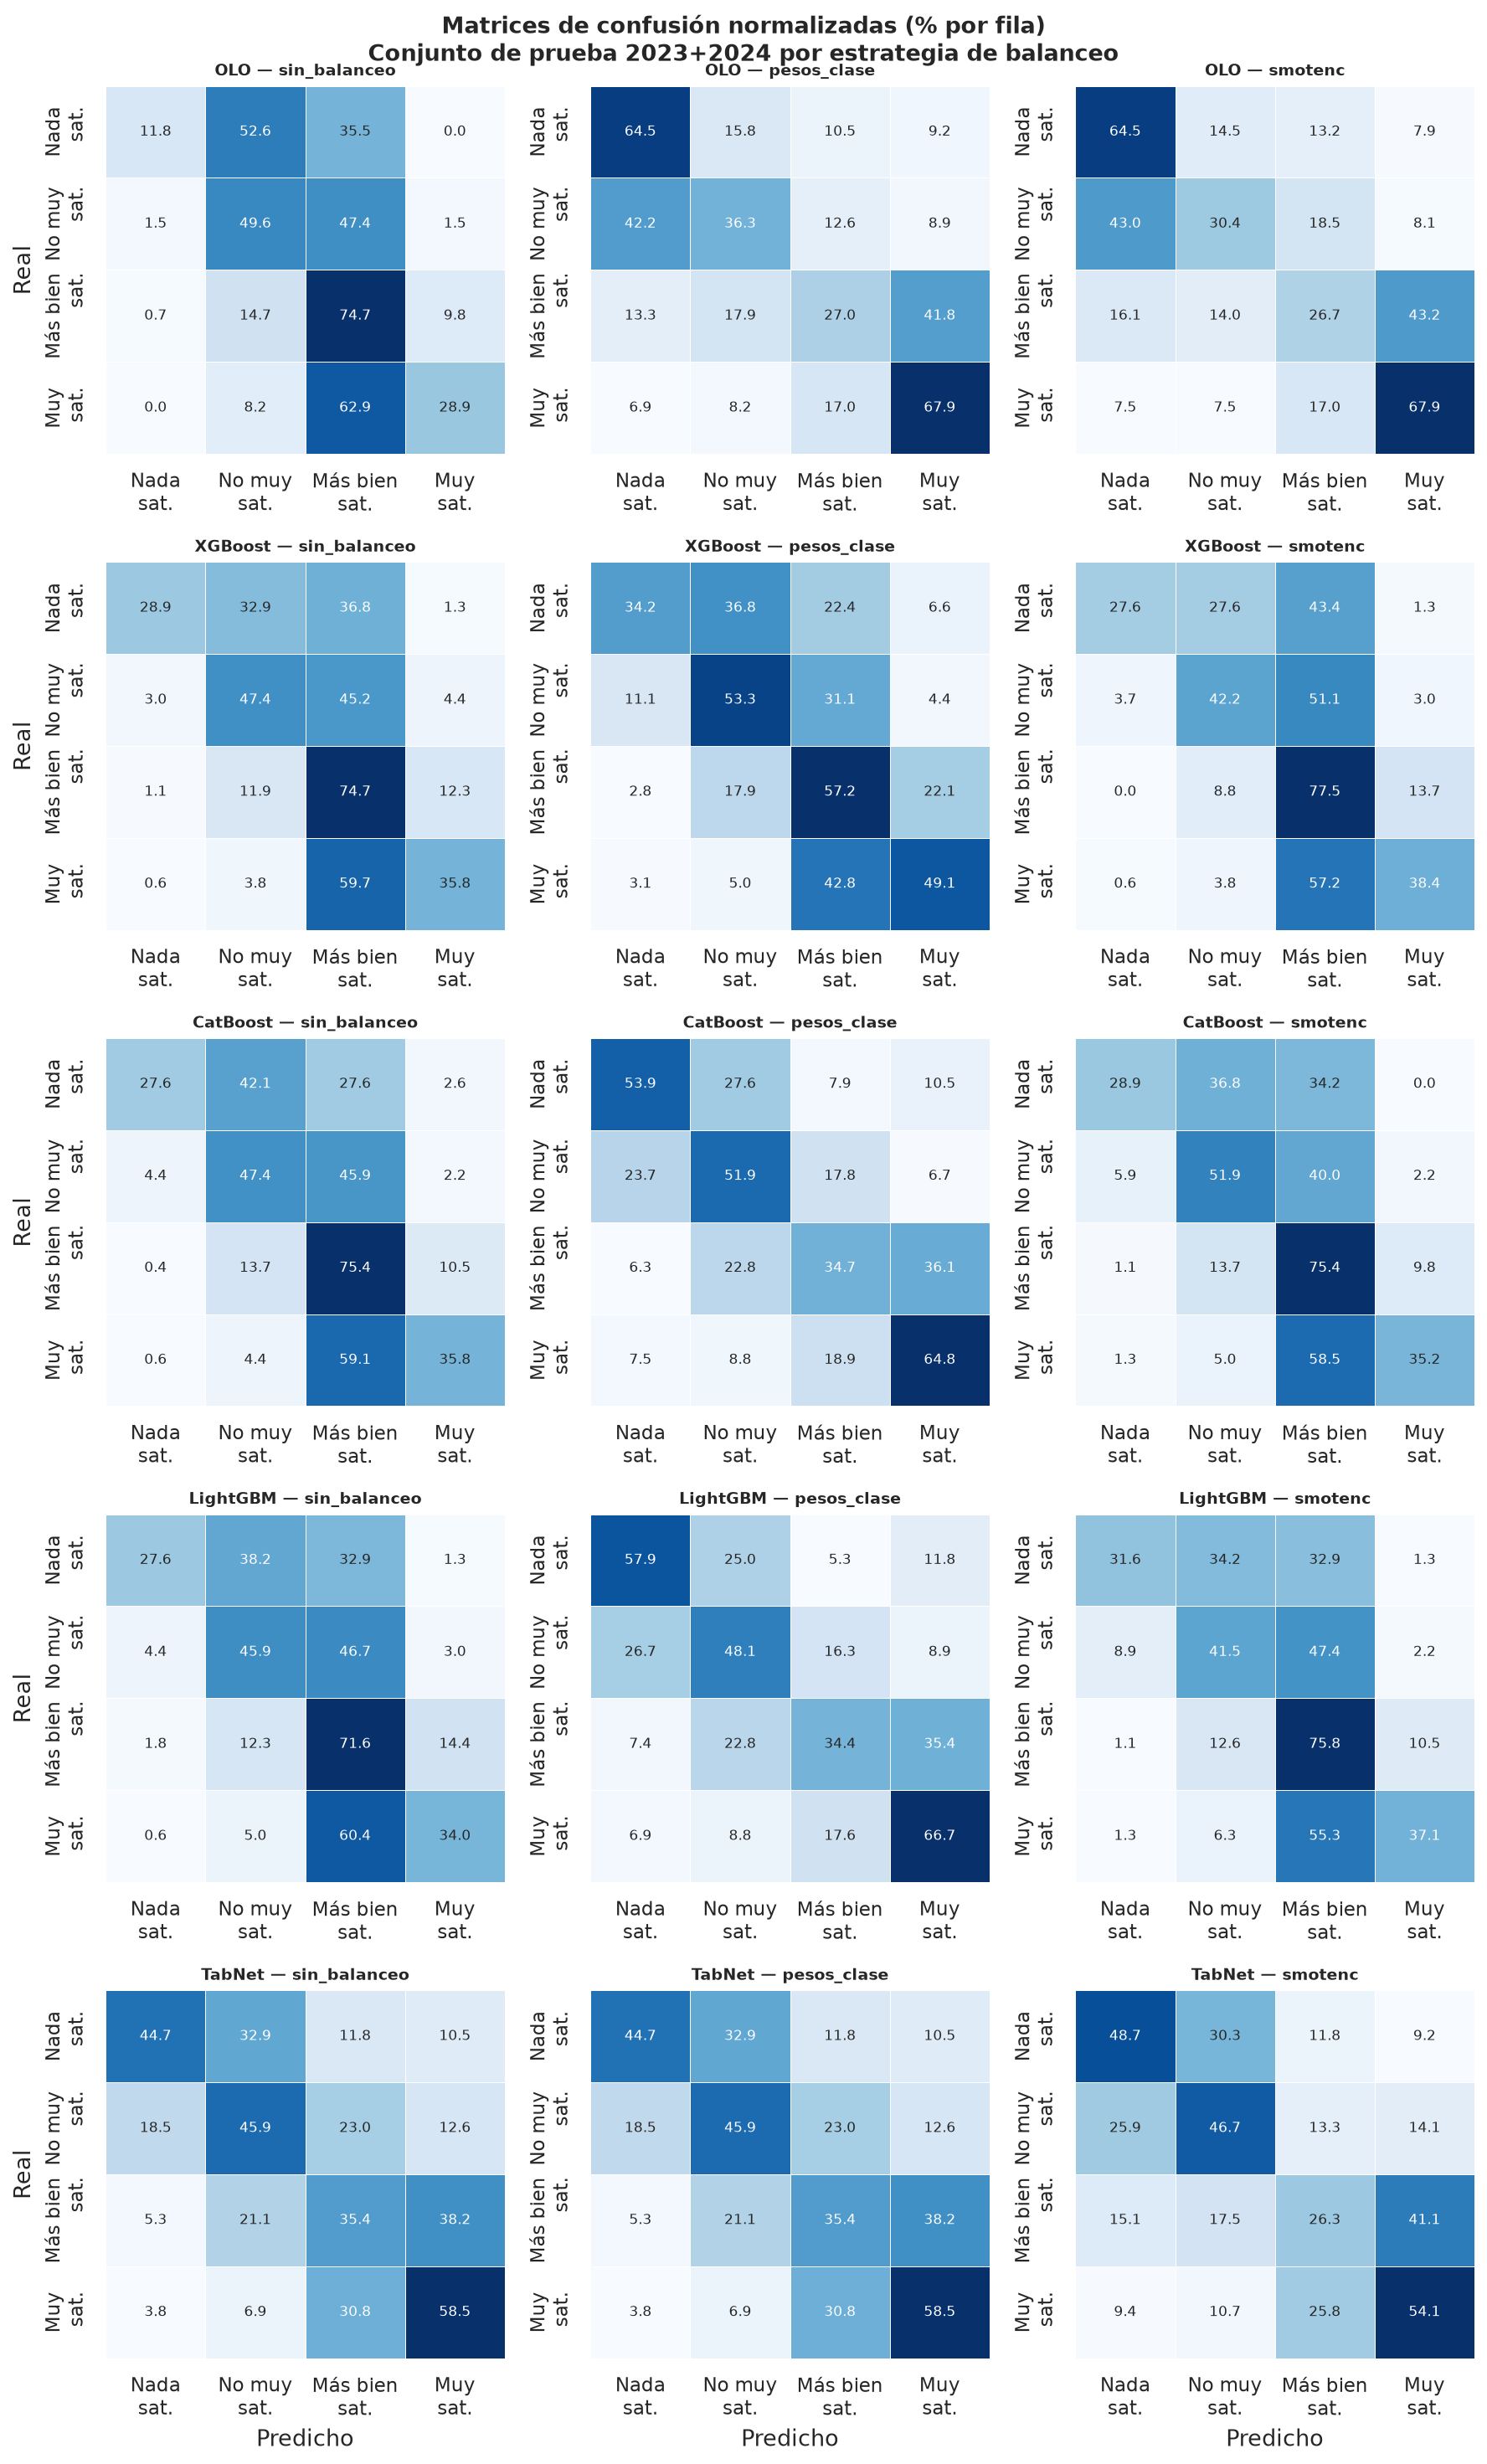

In [7]:
# Mejor modelo global
mejor_global = cargar_mejor_modelo(METRICA_PRINCIPAL)
print(f"Mejor modelo global: {mejor_global}")

plot_matrices_confusion(
    resultados_cm,
    solo_mejor     = not CONFUSION_TODOS_MODELOS,
    mejor_modelo   = mejor_global,
    nombre_archivo = "03_matrices_confusion",
)


## 6. Análisis de rendimiento por subregión y país

In [8]:
# =============================================================================
# MAE ordinal por pais en el conjunto de prueba
# =============================================================================
from sklearn.metrics import mean_absolute_error

filas_pais = []

df_te_full = cargar_split_parquet("test")

if COL_PAIS not in df_te_full.columns:
    print("Advertencia: Columna pais_nombre no disponible en el Parquet de test.")
else:
    y_te_full   = df_te_full[COL_TARGET].astype(int).values
    paises_test = df_te_full[COL_PAIS].unique()
    paises_analizar = [p for p in paises_test if p not in PAISES_EXCLUIR_EVAL]

    for estrat in sorted(df_test["estrategia_balanceo"].unique()):
        for modelo in MODELOS:
            if (modelo, estrat) not in resultados_cm:
                continue
            y_pred_full = resultados_cm[(modelo, estrat)][1]
            for pais in paises_analizar:
                mask = df_te_full[COL_PAIS] == pais
                if mask.sum() < 10:
                    continue
                mae = mean_absolute_error(y_te_full[mask], y_pred_full[mask])
                subregion = "Sin clasificar"
                for sr, paises_sr in SUBREGIONES.items():
                    if pais in paises_sr:
                        subregion = sr
                        break
                filas_pais.append({
                    "modelo": modelo, "estrategia_balanceo": estrat,
                    "pais": pais, "subregion": subregion,
                    "mae_ordinal": mae, "n": int(mask.sum()),
                })

    df_mae_pais = pd.DataFrame(filas_pais)
    if not df_mae_pais.empty:
        print("Analisis por pais (promedio sobre estrategias):")
        print(df_mae_pais.groupby(["subregion", "modelo"])["mae_ordinal"]
              .mean().unstack().round(3).to_string())
        df_mae_pais.to_csv(
            PATHS["FOLDER_RESULTS_TABLES"] / "mae_por_pais_test.csv",
            index=False)
        print("Tabla guardada")
    else:
        print("Sin datos por pais - verificar Parquet de test.")


Analisis por pais (promedio sobre estrategias):
modelo           CatBoost  LightGBM    OLO  TabNet  XGBoost
subregion                                                  
Brasil              0.429     0.476  0.537   0.612    0.435
Centroamérica       0.726     0.711  0.811   0.861    0.701
Cono Sur            0.520     0.549  0.626   0.658    0.497
México y Caribe     0.584     0.607  0.778   0.712    0.514
Región Andina       0.381     0.429  0.545   0.631    0.400
Tabla guardada


  ✓ Figura guardada: 03_mae_por_pais.png


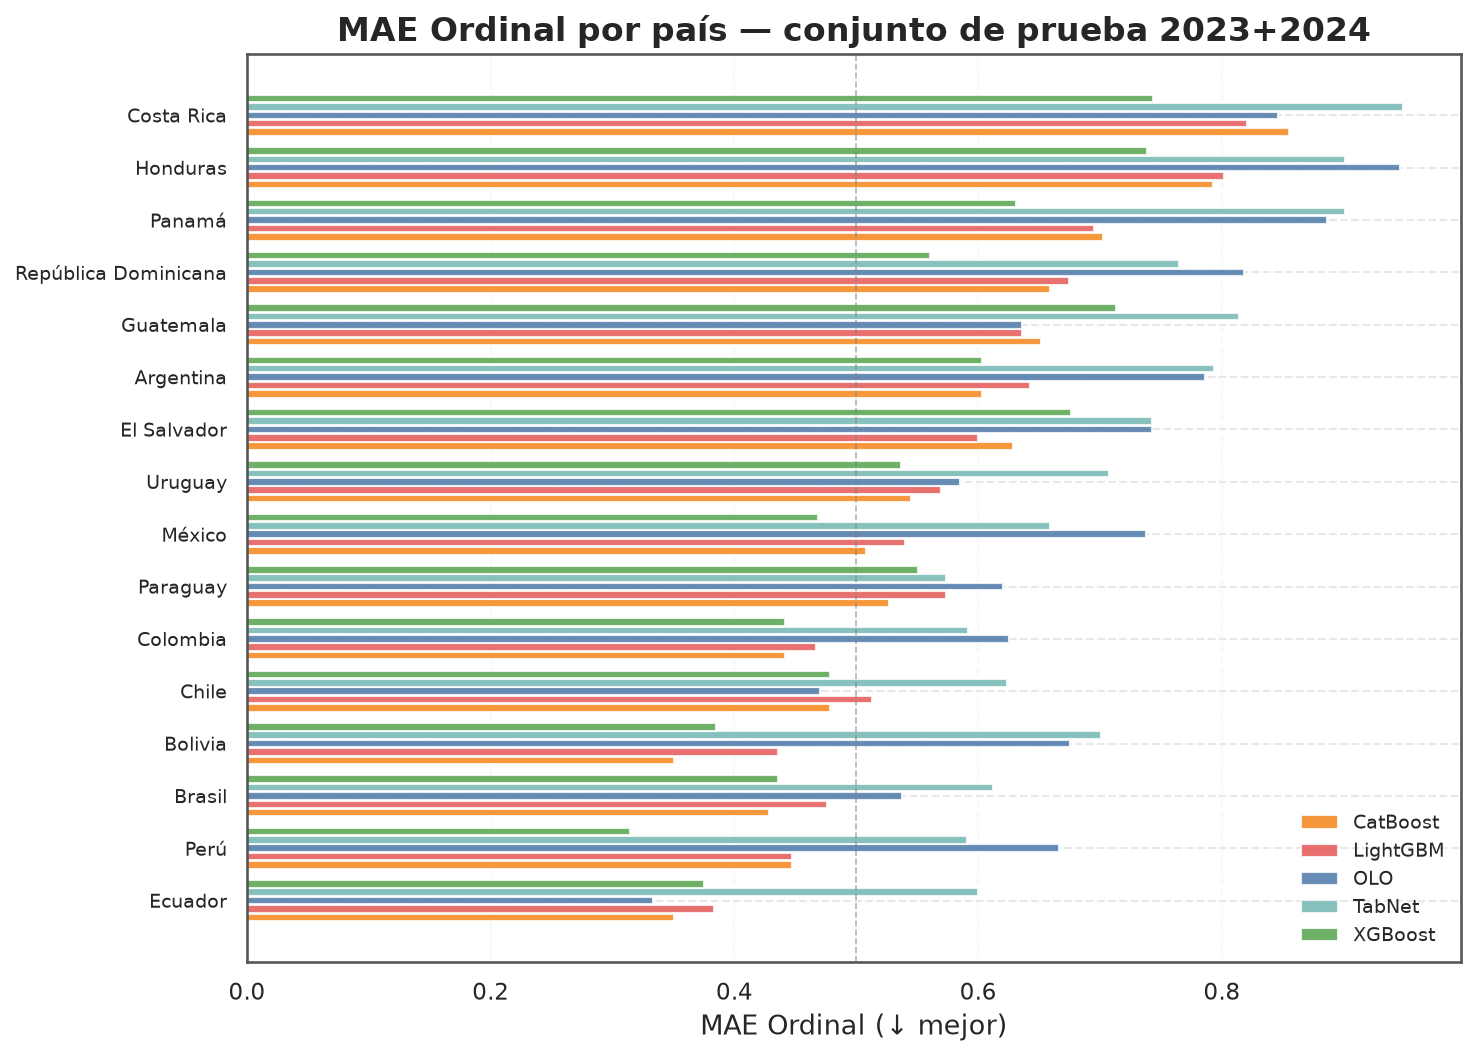

  ✓ Figura guardada: 03_mae_subregion_heatmap.png


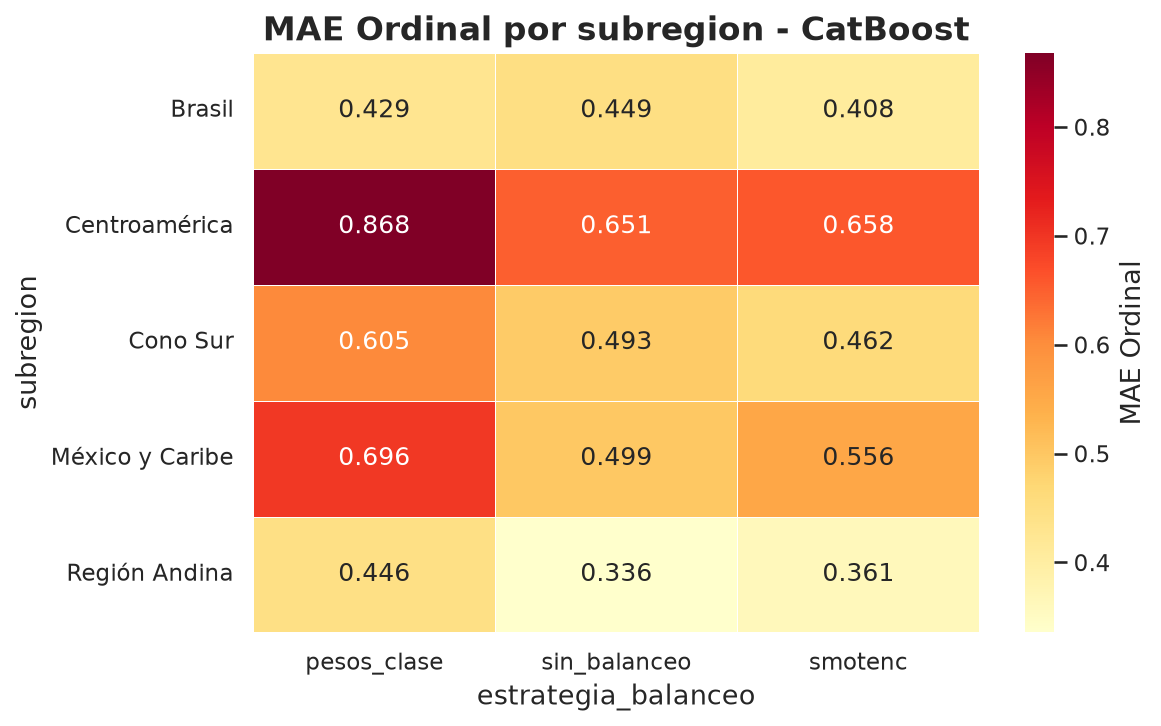

In [9]:
# Grafico MAE por pais (promedio de estrategias)
if "df_mae_pais" in dir() and not df_mae_pais.empty:
    df_mae_mean = df_mae_pais.groupby(["pais", "modelo"], as_index=False)["mae_ordinal"].mean()
    plot_rendimiento_por_pais(df_mae_mean, nombre_archivo="03_mae_por_pais")

# Heatmap: MAE por subregion x estrategia para el mejor modelo
if "df_mae_pais" in dir() and not df_mae_pais.empty:
    mejor_m = cargar_mejor_modelo(METRICA_PRINCIPAL)
    df_sr   = (df_mae_pais[df_mae_pais["modelo"] == mejor_m]
               .groupby(["subregion", "estrategia_balanceo"])["mae_ordinal"]
               .mean()
               .unstack())
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(df_sr, annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.3, ax=ax, cbar_kws={"label": "MAE Ordinal"})
    ax.set_title(f"MAE Ordinal por subregion - {mejor_m}", fontweight="bold")
    save_figure("03_mae_subregion_heatmap")
    plt.show()


## 7. Test estadístico de diferencias entre modelos

**Test de Friedman** (Demšar, 2006): evalúa si las diferencias de rendimiento
entre modelos son estadísticamente significativas considerando todos los
splits como bloques.

**Nota metodológica:** con n=3 splits la potencia estadística es baja.
Los resultados se interpretan como evidencia indicativa, no concluyente.

In [10]:
if EJECUTAR_TEST_ESTADISTICO:
    from scipy.stats import friedmanchisquare

    # Matriz: modelos (tratamientos) x estrategias (bloques)
    estrategias_ord = sorted(df_test["estrategia_balanceo"].unique())
    matriz = []
    for modelo in MODELOS:
        fila = []
        for estrat in estrategias_ord:
            sub = df_test[(df_test["modelo"] == modelo) &
                          (df_test["estrategia_balanceo"] == estrat)]
            fila.append(sub[METRICA_PRINCIPAL].values[0] if len(sub) > 0 else np.nan)
        matriz.append(fila)
    mat = np.array(matriz)   # shape: (n_modelos x n_estrategias)

    stat, p_val = friedmanchisquare(*mat.T)
    print("Test de Friedman")
    print(f"  Estadistico chi2F = {stat:.4f}")
    print(f"  p-valor           = {p_val:.4f}")
    conclusion = "Diferencias significativas (a=0.05)" if p_val < 0.05 else "Sin evidencia de diferencias"
    print(f"  Conclusion        : {conclusion}")
    n_bloques = len(estrategias_ord)
    print(f"  Nota: n={n_bloques} bloques (estrategias). Resultados indicativos.")

    if p_val < 0.05:
        try:
            from scikit_posthocs import posthoc_nemenyi_friedman
            df_nemenyi = posthoc_nemenyi_friedman(mat.T)
            df_nemenyi.index   = MODELOS
            df_nemenyi.columns = MODELOS
            print("Post-hoc Nemenyi (p-valores):")
            print(df_nemenyi.round(4).to_string())
            df_nemenyi.to_csv(PATHS["FOLDER_RESULTS_TABLES"] / "nemenyi_pvalues.csv")
        except ImportError:
            print("  scikit-posthocs no instalado: pip install scikit-posthocs")
else:
    print("Test estadistico desactivado (EJECUTAR_TEST_ESTADISTICO = False)")


Test de Friedman
  Estadistico chi2F = 2.2105
  p-valor           = 0.3311
  Conclusion        : Sin evidencia de diferencias
  Nota: n=3 bloques (estrategias). Resultados indicativos.


## 8. Selección del modelo principal para análisis XAI

In [11]:
# =============================================================================
# Seleccion del modelo principal para XAI
# =============================================================================
mejor_global = df_test.loc[df_test[METRICA_PRINCIPAL].idxmax()]
mejor_modelo_xai    = mejor_global["modelo"]
mejor_estrategia_xai = mejor_global["estrategia_balanceo"]

print(f"Modelo principal para analisis XAI: {mejor_modelo_xai} [{mejor_estrategia_xai}]")
print(f"Criterio: mayor {METRICA_PRINCIPAL} en conjunto de prueba")
print()
print("Ranking completo (test):")
sub_rank = df_test.sort_values(METRICA_PRINCIPAL, ascending=False)
for _, row in sub_rank.iterrows():
    marca = " <- SELECCIONADO" if (row["modelo"] == mejor_modelo_xai and
                                   row["estrategia_balanceo"] == mejor_estrategia_xai) else ""
    print(f"  {row['modelo']:<12} [{row['estrategia_balanceo']:<15}]: "
          f"{METRICA_PRINCIPAL}={row[METRICA_PRINCIPAL]:.4f}{marca}")

seleccion = {
    "modelo_xai"          : mejor_modelo_xai,
    "estrategia_balanceo" : mejor_estrategia_xai,
    "metrica"             : METRICA_PRINCIPAL,
    "split_referencia"    : "test",
}
import json as _json
ruta_sel = PATHS["FOLDER_RESULTS"] / "modelo_xai_seleccionado.json"
ruta_sel.write_text(_json.dumps(seleccion, indent=2))
print(f"Seleccion guardada: {ruta_sel}")


Modelo principal para analisis XAI: CatBoost [sin_balanceo]
Criterio: mayor kappa_cuadratico en conjunto de prueba

Ranking completo (test):
  CatBoost     [sin_balanceo   ]: kappa_cuadratico=0.5385 <- SELECCIONADO
  CatBoost     [smotenc        ]: kappa_cuadratico=0.5348
  XGBoost      [pesos_clase    ]: kappa_cuadratico=0.5250
  LightGBM     [pesos_clase    ]: kappa_cuadratico=0.5236
  LightGBM     [smotenc        ]: kappa_cuadratico=0.5231
  CatBoost     [pesos_clase    ]: kappa_cuadratico=0.5213
  OLO          [pesos_clase    ]: kappa_cuadratico=0.5189
  XGBoost      [sin_balanceo   ]: kappa_cuadratico=0.5125
  XGBoost      [smotenc        ]: kappa_cuadratico=0.5097
  LightGBM     [sin_balanceo   ]: kappa_cuadratico=0.5070
  OLO          [smotenc        ]: kappa_cuadratico=0.5046
  TabNet       [pesos_clase    ]: kappa_cuadratico=0.5006
  TabNet       [sin_balanceo   ]: kappa_cuadratico=0.5006
  OLO          [sin_balanceo   ]: kappa_cuadratico=0.4646
  TabNet       [smotenc        

## 9. Resumen y guardado

In [12]:
# =============================================================================
# Resumen ejecutivo del notebook 03
# =============================================================================
print("=" * 60)
print("RESUMEN - Evaluacion comparativa de modelos")
print("=" * 60)
estrategias_disponibles = sorted(df_test["estrategia_balanceo"].unique())
print(f"  Estrategias evaluadas : {', '.join(estrategias_disponibles)}")
print(f"  Modelos evaluados     : {', '.join(MODELOS)}")
print(f"  Metrica principal     : {METRICA_PRINCIPAL}")
print()
print("Mejor modelo por estrategia (Kappa Cuadratico):")
for estrat in estrategias_disponibles:
    try:
        m = cargar_mejor_modelo(METRICA_PRINCIPAL, estrategia=estrat)
        val = df_test[(df_test["modelo"] == m) &
                      (df_test["estrategia_balanceo"] == estrat)][METRICA_PRINCIPAL].values[0]
        print(f"  {estrat}: {m} ({val:.4f})")
    except Exception as e:
        print(f"  {estrat}: sin datos ({e})")
print()
print("Archivos generados en results/:")
for f in sorted(PATHS["FOLDER_RESULTS_TABLES"].glob("*.csv")):
    print(f"  {f.name}")
for f in sorted(PATHS["FOLDER_RESULTS_FIGURES"].glob("03_*.png")):
    print(f"  {f.name}")


RESUMEN - Evaluacion comparativa de modelos
  Estrategias evaluadas : pesos_clase, sin_balanceo, smotenc
  Modelos evaluados     : OLO, XGBoost, CatBoost, LightGBM, TabNet
  Metrica principal     : kappa_cuadratico

Mejor modelo por estrategia (Kappa Cuadratico):
  pesos_clase: XGBoost (0.5250)
  sin_balanceo: CatBoost (0.5385)
  smotenc: CatBoost (0.5348)

Archivos generados en results/:
  eda_correlacion_año_target.csv
  eda_correlaciones_features.csv
  eda_desbalance_clases.csv
  eda_venezuela_anomalia.csv
  mae_por_pais_test.csv
  metricas_completas_test.csv
  metricas_kappa_pivot.csv
  03_mae_por_pais.png
  03_mae_subregion_heatmap.png
  03_matrices_confusion.png
  03_metricas_comparativas.png
  03_val_vs_test.png
